# (실습) U-Net 사용해보기

## 실습 개요

1) **실습 목적**

- 이번 실습에서는 Semantic Segmentation의 대표적인 모델인 U-Net을 이용하여 입력 이미지마다 어떤 출력값을 가지게 되는지를 직접 확인해봅니다. 개별 이미지와 및 여러 이미지들에 대한 추론 실습을 수행하며, Semantic Segmentation 문제와 그 모델에 대해 이해합니다. 평가 Metric을 이용해 모델의 성능을 측정하는 과정을 수행합니다.

2) **수강 목표**
- Semantic Segmentation 모델인 U-Net을 라이브러리를 이용해 모델을 불러올 수 있다.
- Semantic Segmentation 모델인 U-Net을 개별 이미지 단위로 추론할 수 있다.
- Semantic Segmentation 모델인 U-Net을 여러 장의 이미지에 대해서 추론 및 평가할 수 있다.



### 실습 목차
* 1. 개별 이미지를 이용한 Semantic Segmentation 추론
  * 1.1 Cityscapes 이미지 불러오기
  * 1.2 U-Net를 이용한 싱글 이미지 추론하기

* 2. 여러 장의 이미지를 이용한 Semantic Segmentation 추론
  * 2.1 PascalVOC 데이터셋 불러오기 및 전처리하기
  * 2.2 U-Net를 이용한 여러 이미지 추론하기

### 환경 설정

- 패키지 설치 및 임포트

In [1]:
# MIM을 사용하여 MMCV 설치하기
!pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu121
!pip3 install openmim
!mim install mmengine
!mim install "mmcv==2.1.0"

# MMSegmentation 설치하기
!git clone https://github.com/open-mmlab/mmsegmentation.git
%cd mmsegmentation
!git checkout main
!pip install -e .
!pip install ftfy

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 867.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 98.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 9.0 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 2.3.1
    Uninstalling triton-2.3.1:
      Successfully uninstalled triton-2.3.1
  Attempting uninstall: torch
    Found existing installation: torch 2.3.1+cu121
    Uninstalling torch-2.3.1+cu121:
      Successfully uninstalled torch-2.3.1+cu121
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.18.1+cu121
    Uninstalling torchvision-0.18.1+cu121:
      Successfully uninstalled torchvision-0.18.1+cu121
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.3.1

In [2]:
import mmseg  # segmentation 라이브러리
from mmseg.apis import MMSegInferencer  # segmentation을 위한 추론기
import os  # 운영 체제와 상호 작용하기 위한 라이브러리
import cv2  # 컴퓨터 비전 작업을 위한 OpenCV 라이브러리
import matplotlib.pyplot as plt  # 데이터 시각화를 위한 라이브러리
import numpy as np  # 수학적 연산을 위한 라이브러리

import torch  # 딥러닝 프레임워크 PyTorch를 불러옵니다.
from torch.utils.data import DataLoader  # 데이터 로딩을 위한 DataLoader 라이브러리
import torch.nn.functional as F  # PyTorch의 함수 모듈
import torchvision  # PyTorch의 컴퓨터 비전 라이브러리
import torchvision.transforms as T  # 이미지 변환을 위한 모듈
import torchvision.utils as vutils  # 이미지 처리를 위한 유틸리티 모듈

In [3]:
# seed를 고정합니다.
import random
import torch.backends.cudnn as cudnn

def random_seed(seed_num):
    torch.manual_seed(seed_num)
    torch.cuda.manual_seed(seed_num)
    torch.cuda.manual_seed_all(seed_num)
    cudnn.benchmark = False
    cudnn.deterministic = True
    random.seed(seed_num)

random_seed(42)

In [4]:
# 가속 환경을 설정합니다.
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

## 1. 개별 이미지를 이용한 Semantic Segmentation 추론

```
💡 목차 개요: mmsegmentation 라이브러리를 이용해 Semantic Segmentation 모델을 불러오고 개별 이미지 단위로 추론할 수 있다.
```

- 1.1 Cityscapes 이미지 불러오기
- 1.2 U-Net를 이용한 싱글 이미지 추론하기

### 1.1 이미지 불러오기

> 추론할 Cityscapes 이미지 데이터를 불러옵니다.

#### Cityscapes 데이터 불러오기

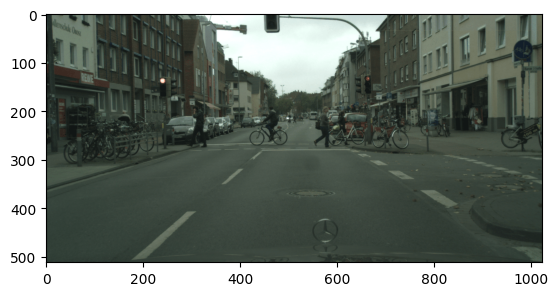

In [5]:
# 입력 이미지를 시각화합니다.
image_1 = cv2.imread("demo/demo.png")
plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))

### 1.2 U-Net를 이용한 싱글 이미지 추론하기

> Semantic Segmentation 모델 중 하나인 U-Net 모델을 이용한 Semantic Segmentation 태스크를 수행합니다.

#### 모델 불러오기

mmsegmentation 라이브러리에서 제공하는 U-Net 모델을 불러옵니다. 해당 U-Net 모델은 Cityscapes의 데이터 셋으로 학습된 모델입니다.

In [6]:
# U-Net모델을 불러옵니다.
model_config = 'unet-s5-d16_fcn_4xb4-160k_cityscapes-512x1024'
inferencer = MMSegInferencer(model=model_config, device=device)

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmsegmentation/v0.5/unet/fcn_unet_s5-d16_4x4_512x1024_160k_cityscapes/fcn_unet_s5-d16_4x4_512x1024_160k_cityscapes_20211210_145204-6860854e.pth


Downloading: "https://download.openmmlab.com/mmsegmentation/v0.5/unet/fcn_unet_s5-d16_4x4_512x1024_160k_cityscapes/fcn_unet_s5-d16_4x4_512x1024_160k_cityscapes_20211210_145204-6860854e.pth" to /root/.cache/torch/hub/checkpoints/fcn_unet_s5-d16_4x4_512x1024_160k_cityscapes_20211210_145204-6860854e.pth
/content/mmsegmentation/mmseg/models/losses/cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


07/29 09:11:34 - mmengine - WARNING - Failed to search registry with scope "mmseg" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmseg" is a correct scope, or whether the registry is initialized.


/usr/local/lib/python3.10/dist-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


#### 싱글 이미지 추론하기

In [7]:
# pre-train U-Net모델을 이용해 추론합니다.
result = inferencer('demo/demo.png', show=True, img_out_dir='/content/result_demo.jpg')

# Segmentation mask를 획득합니다.
segmentation_mask = result['predictions']

Output()

#### 추론 결과 시각화하기

In [ ]:
# class별 시각화 색상을 지정합니다.
color_mapping = {
    0: [0, 0, 0],        # Class 0 (배경) - 검은색
    1: [255, 0, 0],      # Class 1 - 빨간색
    2: [0, 255, 0],      # Class 2 - 녹색
    3: [0, 0, 255],      # Class 3 - 파란색
    4: [255, 255, 0],    # Class 4 - 노란색
    5: [255, 0, 255],    # Class 5 - 자홍색
    6: [0, 255, 255],    # Class 6 - 청록색
    7: [128, 0, 0],      # Class 7 - 짙은 빨간색
    8: [0, 128, 0],      # Class 8 - 짙은 녹색
    9: [0, 0, 128],      # Class 9 - 짙은 파란색
    10: [128, 128, 0],   # Class 10 - 올리브색
    11: [128, 0, 128],   # Class 11 - 보라색
    12: [0, 128, 128],   # Class 12 - 하늘색
    13: [192, 192, 192], # Class 13 - 회색
    14: [128, 128, 128], # Class 14 - 짙은 회색
    15: [64, 0, 0],      # Class 15 - 짙은 갈색
    16: [192, 0, 0],     # Class 16 - 밝은 빨간색
    17: [64, 128, 0],    # Class 17 - 라임색
    18: [192, 128, 0]    # Class 18 - 주황색
}

# 원본 이미지와 동일한 크기의 빈 이미지를 생성합니다.
visualized_image = image_1.copy()

# 색상 매핑을 분할 마스크에 적용하고 시각화 이미지 위에 그립니다.
for class_id, color in color_mapping.items():
    visualized_image[segmentation_mask == class_id] = color

# 이미지 시각화를 표시합니다.
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualized_image)
plt.title("Segmentation Result")
plt.axis('off')

plt.show()

## 2. 여러 장의 이미지를 이용한 Semantic Segmentation 추론

```
💡 목차 개요: 라이브러리를 이용해 Semantic Segmentation 모델을 불러오고 여러 이미지들을 추론할 수 있다.
```

- 2.1 PascalVOC 데이터셋 불러오기 및 전처리하기
- 2.2 U-Net를 이용한 여러 이미지 추론하기

### 2.1 PascalVOC 데이터셋 불러오기 및 전처리하기

#### 이미지 데이터셋 불러오기

In [ ]:
# torchvision 라이브러리로 데이터셋 불러오기 및 이미지 전처리를 수행합니다.
voc_data = torchvision.datasets.VOCSegmentation('./', year='2012', image_set='val', download=True)

100%|██████████| 1999639040/1999639040 [02:07<00:00, 15695991.29it/s]


Extracting ./VOCtrainval_11-May-2012.tar to ./


In [ ]:
!ls VOCdevkit/VOC2012/SegmentationClass/

2007_000032.png  2007_009435.png  2008_006553.png  2009_004091.png  2010_004365.png
2007_000033.png  2007_009436.png  2008_006554.png  2009_004095.png  2010_004369.png
2007_000039.png  2007_009446.png  2008_006558.png  2009_004099.png  2010_004370.png
2007_000042.png  2007_009458.png  2008_006655.png  2009_004105.png  2010_004382.png
2007_000061.png  2007_009464.png  2008_006703.png  2009_004117.png  2010_004419.png
2007_000063.png  2007_009521.png  2008_006722.png  2009_004125.png  2010_004429.png
2007_000068.png  2007_009527.png  2008_006748.png  2009_004140.png  2010_004432.png
2007_000121.png  2007_009533.png  2008_006751.png  2009_004171.png  2010_004450.png
2007_000123.png  2007_009550.png  2008_006752.png  2009_004178.png  2010_004472.png
2007_000129.png  2007_009554.png  2008_006784.png  2009_004180.png  2010_004478.png
2007_000170.png  2007_009562.png  2008_006835.png  2009_004186.png  2010_004479.png
2007_000175.png  2007_009580.png  2008_006843.png  2009_004191.png  2010_004

In [ ]:
# 실습에 사용할 이미지를 전처리 합니다.
data_path = 'VOCdevkit/VOC2012/JPEGImages'
image_list = os.listdir(data_path)
rewrite_path = 'NewResizedImages'
os.makedirs(rewrite_path, exist_ok=True)
# 최대 5개의 이미지만 이용합니다.
num_images = 5
image_file = ['2008_003846.jpg', '2007_000042.jpg', '2008_003947.jpg', '2008_003986.jpg', '2008_004055.jpg']

resized_images = []
for f in image_file:
    image = cv2.cvtColor(cv2.imread(os.path.join(data_path, f)), cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image, dsize=(1024,512))
    resized_images.append(resized_image)
    cv2.imwrite(os.path.join(rewrite_path, f), resized_image)

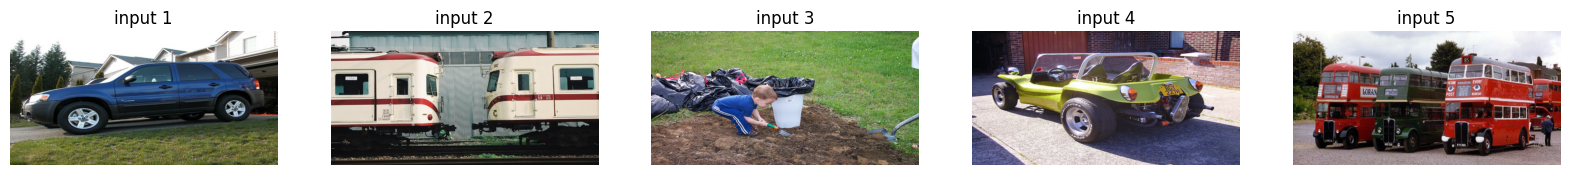

In [ ]:
# 시각화하는 크기를 설정합니다.
plt.figure(figsize=(20, 10))

# 이미지를 시각화합니다.
for i, resized_image in enumerate(resized_images):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(resized_image)
    plt.title(f'input {i + 1}')
    plt.axis('off')
plt.show()

### 2.2 U-Net를 이용한 여러 이미지 추론하기

#### 여러 이미지 추론하기

In [ ]:
# pre-train 모델로 추론합니다.
result = inferencer(resized_images, show=False, out_dir=f'_results/imgs_{i}')

Output()

In [ ]:
# 예측 결과를 바탕으로 평가를 위한 Segmentation Mask를 생성합니다.
# 이 때 실습 복잡도를 줄이고자 가장 큰 영역으로 예측된 클래스 하나에 대해서만 segmentation mask를 가져옵니다.
seg_map_preds = [] # seg_map_preds 저장할 리스트 생성합니다.
for prediction in result['predictions']:
    max = 0
    seg_map_pred = None
    for class_id in color_mapping.keys():
      per_class_map = np.where(prediction == class_id, class_id, 0)
      if np.sum(per_class_map != 0) > max:
        max = np.sum(per_class_map != 0)
        seg_map_pred = per_class_map
    seg_map_preds.append(seg_map_pred)

In [ ]:
# Ground Truth 결과 이미지를 불러와서 resize를 진행합니다.
# ## GT Segmentation Map 파일 경로
gt_image_paths = [
    '/content/mmsegmentation/VOCdevkit/VOC2012/SegmentationClass/2008_003846.png',
    '/content/mmsegmentation/VOCdevkit/VOC2012/SegmentationClass/2007_000042.png',
    '/content/mmsegmentation/VOCdevkit/VOC2012/SegmentationClass/2008_003947.png',
    '/content/mmsegmentation/VOCdevkit/VOC2012/SegmentationClass/2008_003986.png',
    '/content/mmsegmentation/VOCdevkit/VOC2012/SegmentationClass/2008_004055.png'
]

# # GT Segmentation Map을 로드합니다.
seg_map_gts = []

for image_path in gt_image_paths:
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB) # 이미지 로드
    resized_image = cv2.resize(image, dsize=(1024,512)) # 이미지 resize
    seg_map_gt = np.where(np.all(resized_image == [0, 0, 0], axis=-1), 0, 1)
    seg_map_gts.append(seg_map_gt)

In [ ]:
# IoU metric을 구현합니다.
iou_scores = []
for i in range(len(seg_map_gts)):  # 5개의 segmentation mask에 대해 반복합니다.
  intersection = torch.logical_and(torch.from_numpy(seg_map_preds[i]), torch.from_numpy(seg_map_gts[i])).sum()
  union = torch.logical_or(torch.from_numpy(seg_map_preds[i]), torch.from_numpy(seg_map_gts[i])).sum()
  iou = intersection.item() / union.item()
  iou_scores.append(iou)

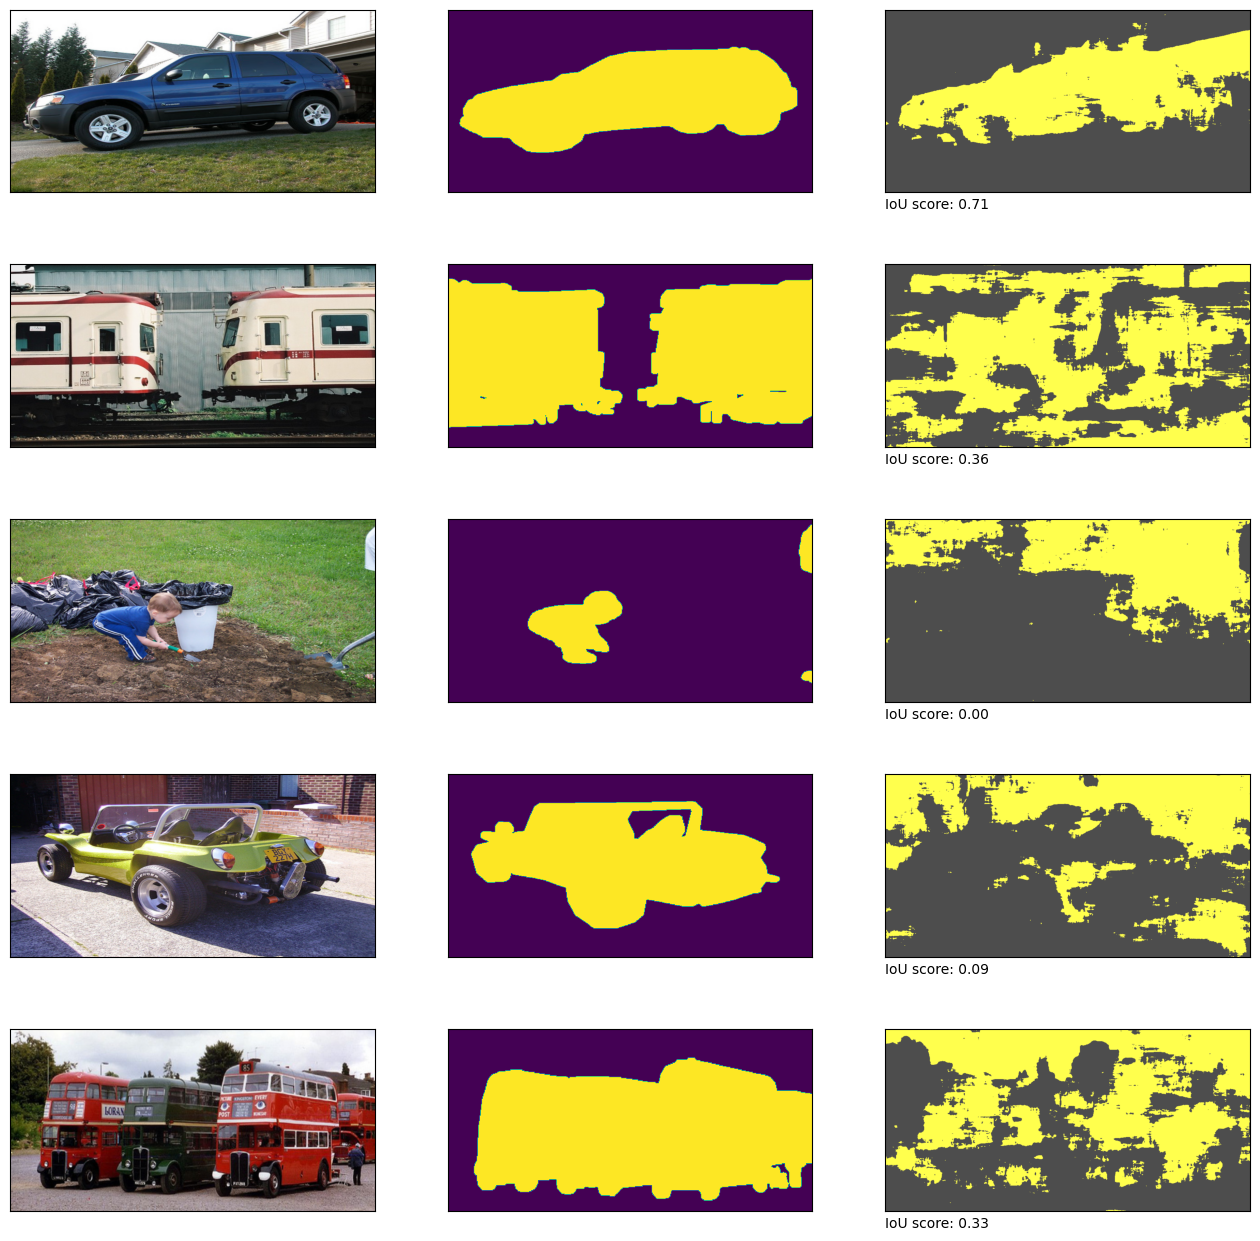

Average IoU score : 0.2983091301031004


In [ ]:
# 결과 이미지를 시각화합니다.
plt.figure(figsize = (16,16))

for i, (resized_image, seg_map_gt, seg_map_pred, iou) in enumerate(zip(resized_images, seg_map_gts, seg_map_preds, iou_scores)):
    # 원본 이미지를 시각화합니다.
    plt.subplot(5,3,i*3+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(resized_image)


    # Ground Truth Mask 이미지를 시각화합니다.

    plt.subplot(5,3,i*3+2)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(seg_map_gt)

    # Pred Mask를 시각화 합니다.
    # 원본 이미지와 동일한 크기의 빈 이미지를 생성합니다.
    visualized_image = np.zeros(resized_image.shape)

    # 색상 매핑을 결과물인 분할 마스크에 적용하고 시각화 이미지 위에 그립니다.
    visualized_image[seg_map_pred != 0] = [255, 255, 0]

    # 이미지 시각화를 표시하고 IoU score를 표기합니다.
    plt.subplot(5,3,i*3+3)
    plt.xlabel("IoU score: {:.2f}".format(iou_scores[i]), loc='left')
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(visualized_image.astype(int), alpha=0.7)
plt.show()  # 플롯을 표시합니다.

print("Average IoU score :", sum(iou_scores) / len(iou_scores))


#### 추론 결과 시각화하기

### Reference
- U-Net GitHub Repository  [homepage](https://github.com/milesial/Pytorch-UNet)

- credits:
  - 이미지: Cityscapes Image Dataset [homepage](https://www.cityscapes-dataset.com/)
  - 이미지: Pascal VOC Image Dataset [homepage](http://host.robots.ox.ac.uk/pascal/VOC/)


## Required Package

- torch == 2.0.1
- torchvision == 0.16.0
- cv2 == 4.8.0
- mmsegmentation


## 콘텐츠 라이선스

저작권 : <font color='blue'> <b> ©2023 by Upstage X fastcampus Co., Ltd. All rights reserved.</font></b>

<font color='red'><b>WARNING</font> : 본 교육 콘텐츠의 지식재산권은 업스테이지 및 패스트캠퍼스에 귀속됩니다. 본 콘텐츠를 어떠한 경로로든 외부로 유출 및 수정하는 행위를 엄격히 금합니다. </b>